In [ ]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import missingno as msno
from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler


In [ ]:
df_test = pd.read_csv("/content/drive/MyDrive/miuul/test.csv")
df_train = pd.read_csv("/content/drive/MyDrive/miuul/train.csv")
df = pd.concat([df_train, df_test], ignore_index=True)

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)


In [ ]:
df.head()
df.shape
df.info()
df["SalePrice"].describe().T
df.isnull().sum()
df.nunique()
df.describe().T

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706.000,Unf,0.000,150.000,856.000,GasA,Ex,Y,SBrkr,856,854,0,1710,1.000,0.000,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2.000,548.000,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.000
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.000,Unf,0.000,284.000,1262.000,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.000,1.000,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2.000,460.000,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.000
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.000,Unf,0.000,434.000,920.000,GasA,Ex,Y,SBrkr,920,866,0,1786,1.000,0.000,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2.000,608.000,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.000
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216.000,Unf,0.000,540.000,756.000,GasA,Gd,Y,SBrkr,961,756,0,1717,1.000,0.000,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3.000,642.000,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655.000,Unf,0.000,490.000,1145.000,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.000,0.000,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3.000,836.000,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.000


(2919, 81)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

,SalePrice
count,1460.000
mean,180921.196
std,79442.503
min,34900.000
25%,129975.000
50%,163000.000
75%,214000.000
max,755000.000


,0
Id,0
MSSubClass,0
MSZoning,4
LotFrontage,486
LotArea,0
Street,0
Alley,2721
LotShape,0
LandContour,0
Utilities,2


,0
Id,2919
MSSubClass,16
MSZoning,5
LotFrontage,128
LotArea,1951
Street,2
Alley,2
LotShape,4
LandContour,4
Utilities,2


,count,mean,std,min,25%,50%,75%,max
Id,2919.000,1460.000,842.787,1.000,730.500,1460.000,2189.500,2919.000
MSSubClass,2919.000,57.138,42.518,20.000,20.000,50.000,70.000,190.000
LotFrontage,2433.000,69.306,23.345,21.000,59.000,68.000,80.000,313.000
LotArea,2919.000,10168.114,7886.996,1300.000,7478.000,9453.000,11570.000,215245.000
OverallQual,2919.000,6.089,1.410,1.000,5.000,6.000,7.000,10.000
OverallCond,2919.000,5.565,1.113,1.000,5.000,5.000,6.000,9.000
YearBuilt,2919.000,1971.313,30.291,1872.000,1953.500,1973.000,2001.000,2010.000
YearRemodAdd,2919.000,1984.264,20.894,1950.000,1965.000,1993.000,2004.000,2010.000
MasVnrArea,2896.000,102.201,179.334,0.000,0.000,0.000,164.000,1600.000
BsmtFinSF1,2918.000,441.423,455.611,0.000,0.000,368.500,733.000,5644.000


In [ ]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """

    Veri setindeki kategorik, numerik ve kategorik fakat kardinal değişkenlerin isimlerini verir.
    Not: Kategorik değişkenlerin içerisine numerik görünümlü kategorik değişkenler de dahildir.

    Parameters
    ------
        dataframe: dataframe
                Değişken isimleri alınmak istenilen dataframe
        cat_th: int, optional
                numerik fakat kategorik olan değişkenler için sınıf eşik değeri
        car_th: int, optinal
                kategorik fakat kardinal değişkenler için sınıf eşik değeri

    Returns
    ------
        cat_cols: list
                Kategorik değişken listesi
        num_cols: list
                Numerik değişken listesi
        cat_but_car: list
                Kategorik görünümlü kardinal değişken listesi

    Examples
    ------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))


    Notes
    ------
        cat_cols + num_cols + cat_but_car = toplam değişken sayısı
        num_but_cat cat_cols'un içerisinde.
        Return olan 3 liste toplamı toplam değişken sayısına eşittir: cat_cols + num_cols + cat_but_car = değişken sayısı

    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)
cat_cols
num_cols
cat_but_car


Observations: 2919
Variables: 81
cat_cols: 52
num_cols: 28
cat_but_car: 1
num_but_cat: 10


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition',
 'OverallCond',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'Fireplaces',
 'GarageCars',
 'YrSold']

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'TotRmsAbvGrd',
 'GarageYrBlt',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'SalePrice']

['Neighborhood']

In [ ]:
df["MSSubClass"] = df["MSSubClass"].astype(str)
cat_cols, num_cols, cat_but_car = grab_col_names(df)
num_cols = [col for col in num_cols if col not in ["Id"]]

Observations: 2919
Variables: 81
cat_cols: 53
num_cols: 27
cat_but_car: 1
num_but_cat: 10


            MSSubClass  Ratio
MSSubClass                   
20                1079 36.965
60                 575 19.699
50                 287  9.832
120                182  6.235
30                 139  4.762
70                 128  4.385
160                128  4.385
80                 118  4.042
90                 109  3.734
190                 61  2.090
85                  48  1.644
75                  23  0.788
45                  18  0.617
180                 17  0.582
40                   6  0.206
150                  1  0.034
##########################################
          MSZoning  Ratio
MSZoning                 
RL            2265 77.595
RM             460 15.759
FV             139  4.762
RH              26  0.891
C (all)         25  0.856
##########################################
        Street  Ratio
Street               
Pave      2907 99.589
Grvl        12  0.411
##########################################
       Alley  Ratio
Alley              
Grvl     120  4.111
P

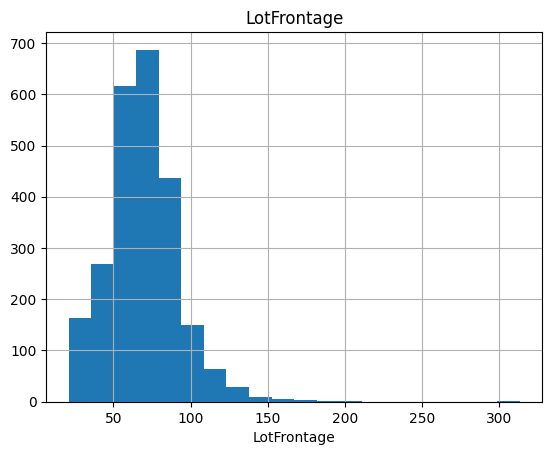

count     2919.000
mean     10168.114
std       7886.996
min       1300.000
5%        3182.000
10%       4922.400
20%       7007.600
30%       7960.400
40%       8741.000
50%       9453.000
60%      10151.600
70%      11001.200
80%      12203.800
90%      14300.600
95%      17142.900
99%      33038.640
max     215245.000
Name: LotArea, dtype: float64
##########################################


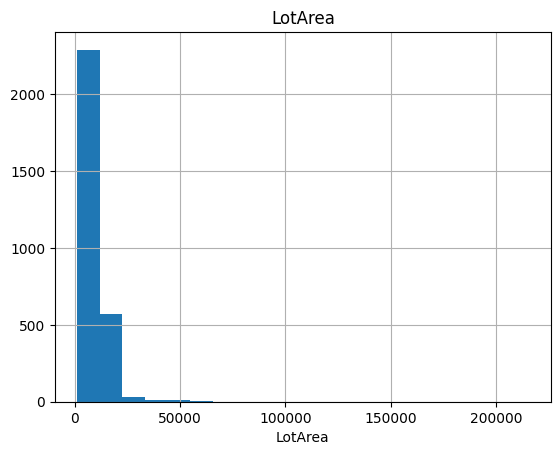

count   2919.000
mean       6.089
std        1.410
min        1.000
5%         4.000
10%        5.000
20%        5.000
30%        5.000
40%        6.000
50%        6.000
60%        6.000
70%        7.000
80%        7.000
90%        8.000
95%        8.000
99%       10.000
max       10.000
Name: OverallQual, dtype: float64
##########################################


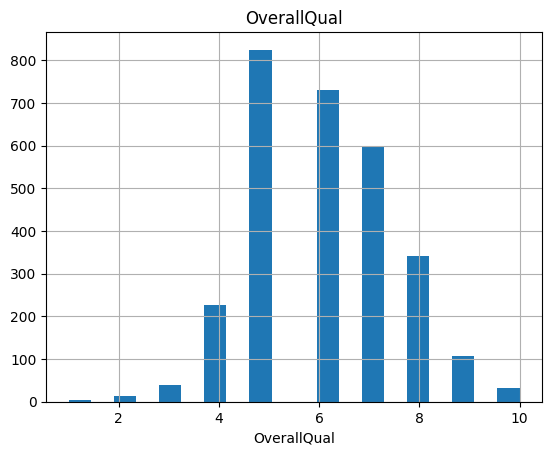

count   2919.000
mean    1971.313
std       30.291
min     1872.000
5%      1915.000
10%     1924.000
20%     1947.000
30%     1957.000
40%     1965.000
50%     1973.000
60%     1984.000
70%     1998.000
80%     2003.000
90%     2006.000
95%     2007.000
99%     2008.000
max     2010.000
Name: YearBuilt, dtype: float64
##########################################


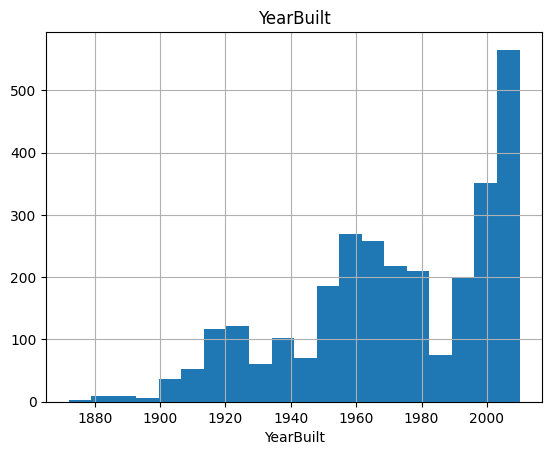

count   2919.000
mean    1984.264
std       20.894
min     1950.000
5%      1950.000
10%     1950.000
20%     1960.000
30%     1970.000
40%     1978.000
50%     1993.000
60%     1998.000
70%     2002.000
80%     2005.000
90%     2006.200
95%     2007.000
99%     2009.000
max     2010.000
Name: YearRemodAdd, dtype: float64
##########################################


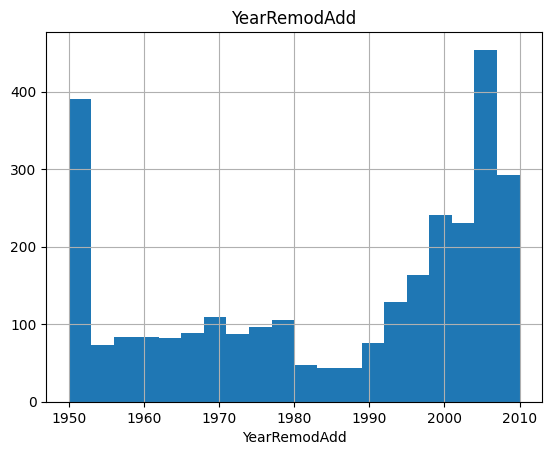

count   2896.000
mean     102.201
std      179.334
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%        0.000
50%        0.000
60%        0.000
70%      120.000
80%      202.000
90%      325.500
95%      466.500
99%      771.050
max     1600.000
Name: MasVnrArea, dtype: float64
##########################################


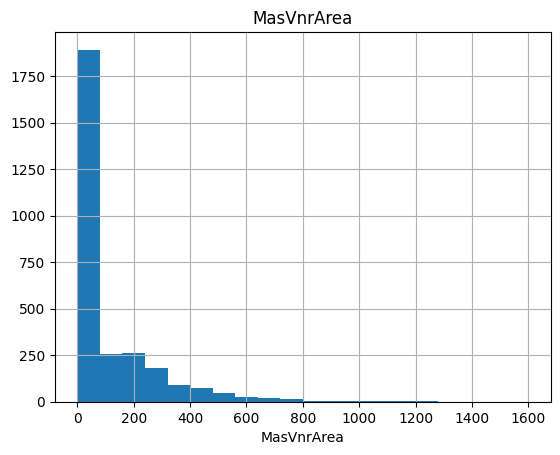

count   2918.000
mean     441.423
std      455.611
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%      202.600
50%      368.500
60%      515.200
70%      656.000
80%      812.000
90%     1056.900
95%     1274.000
99%     1635.320
max     5644.000
Name: BsmtFinSF1, dtype: float64
##########################################


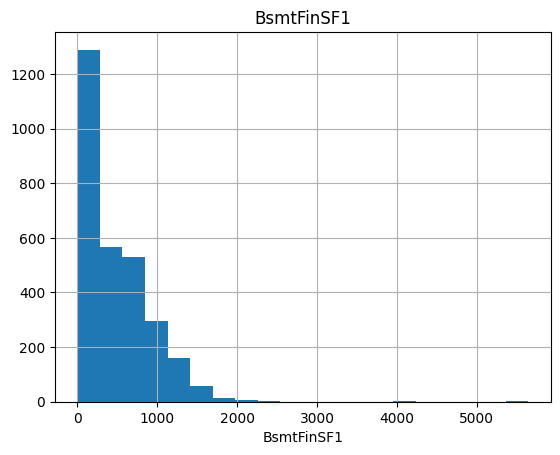

count   2918.000
mean      49.582
std      169.206
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%        0.000
50%        0.000
60%        0.000
70%        0.000
80%        0.000
90%      125.600
95%      435.000
99%      874.660
max     1526.000
Name: BsmtFinSF2, dtype: float64
##########################################


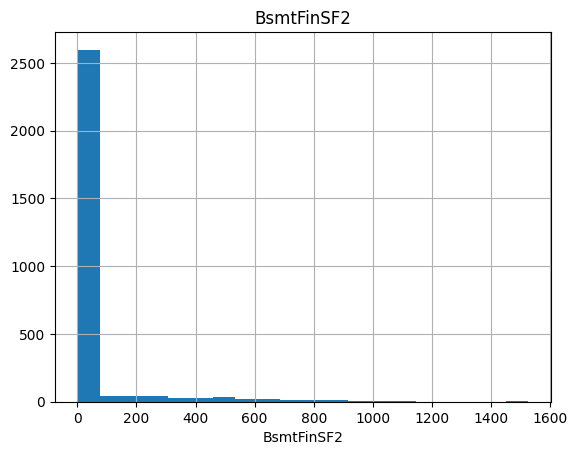

count   2918.000
mean     560.772
std      439.544
min        0.000
5%         0.000
10%       56.000
20%      174.000
30%      270.000
40%      365.800
50%      467.000
60%      595.000
70%      732.000
80%      892.600
90%     1212.600
95%     1474.900
99%     1776.490
max     2336.000
Name: BsmtUnfSF, dtype: float64
##########################################


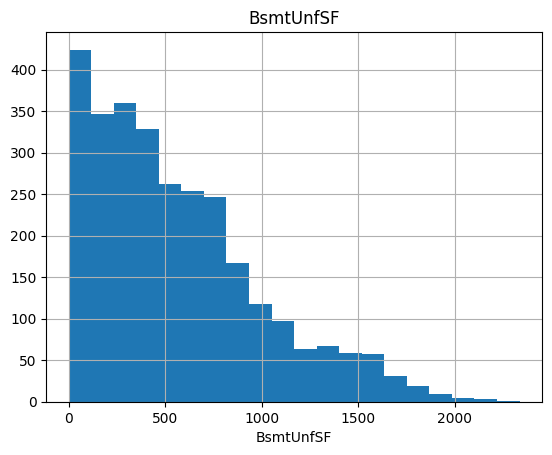

count   2918.000
mean    1051.778
std      440.766
min        0.000
5%       455.250
10%      600.000
20%      741.000
30%      836.000
40%      911.000
50%      989.500
60%     1089.200
70%     1216.000
80%     1392.000
90%     1614.000
95%     1776.150
99%     2198.300
max     6110.000
Name: TotalBsmtSF, dtype: float64
##########################################


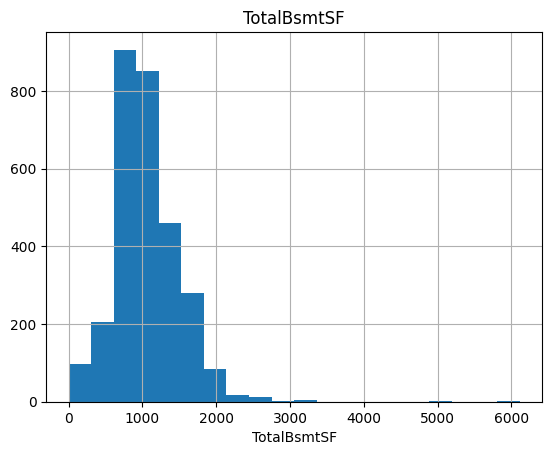

count   2919.000
mean    1159.582
std      392.362
min      334.000
5%       665.900
10%      744.800
20%      847.000
30%      914.000
40%      996.200
50%     1082.000
60%     1180.000
70%     1314.000
80%     1483.400
90%     1675.000
95%     1830.100
99%     2288.020
max     5095.000
Name: 1stFlrSF, dtype: float64
##########################################


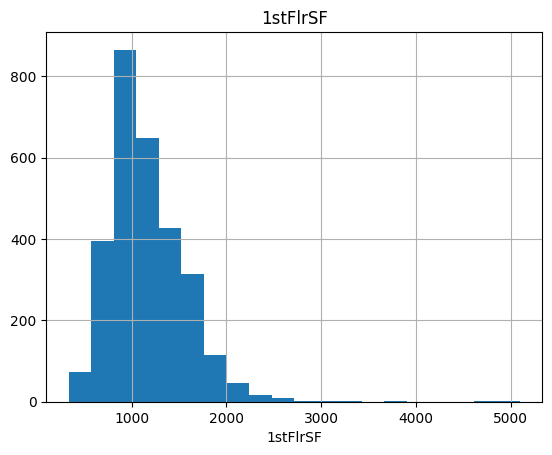

count   2919.000
mean     336.484
std      428.701
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%        0.000
50%        0.000
60%      427.400
70%      636.000
80%      770.800
90%      925.000
95%     1131.200
99%     1400.200
max     2065.000
Name: 2ndFlrSF, dtype: float64
##########################################


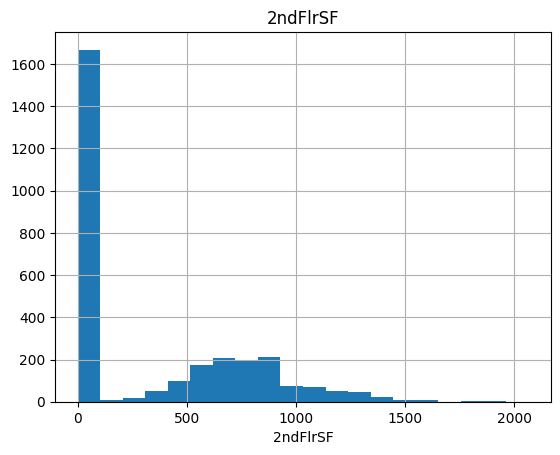

count   2919.000
mean       4.694
std       46.397
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%        0.000
50%        0.000
60%        0.000
70%        0.000
80%        0.000
90%        0.000
95%        0.000
99%      153.840
max     1064.000
Name: LowQualFinSF, dtype: float64
##########################################


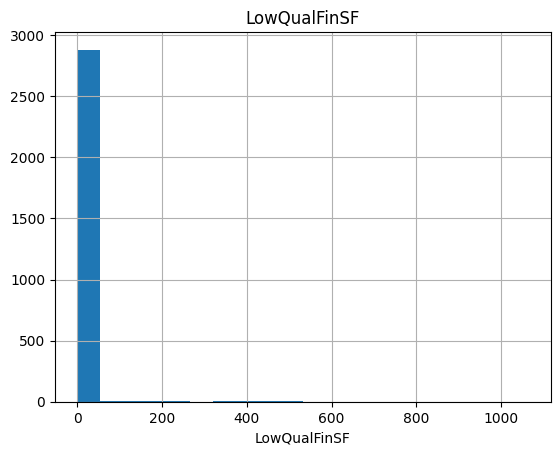

count   2919.000
mean    1500.760
std      506.051
min      334.000
5%       861.000
10%      923.800
20%     1064.600
30%     1200.000
40%     1329.200
50%     1444.000
60%     1560.000
70%     1680.000
80%     1838.400
90%     2153.200
95%     2464.200
99%     2935.720
max     5642.000
Name: GrLivArea, dtype: float64
##########################################


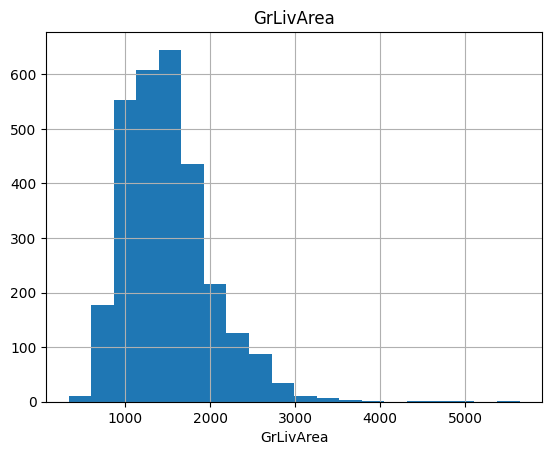

count   2919.000
mean       6.452
std        1.569
min        2.000
5%         4.000
10%        5.000
20%        5.000
30%        6.000
40%        6.000
50%        6.000
60%        7.000
70%        7.000
80%        8.000
90%        8.000
95%        9.000
99%       11.000
max       15.000
Name: TotRmsAbvGrd, dtype: float64
##########################################


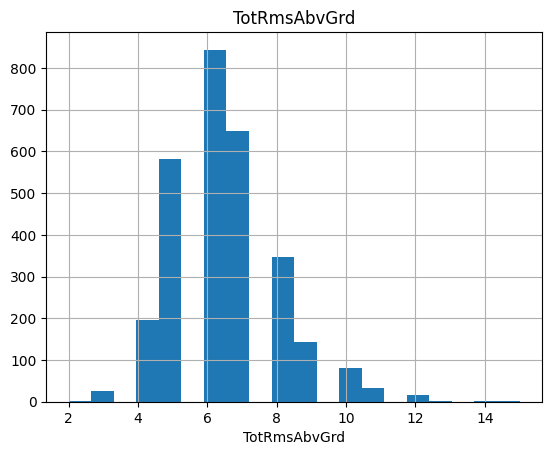

count   2760.000
mean    1978.113
std       25.574
min     1895.000
5%      1928.000
10%     1941.000
20%     1957.000
30%     1964.000
40%     1972.000
50%     1979.000
60%     1993.000
70%     1999.000
80%     2004.000
90%     2006.000
95%     2007.000
99%     2009.000
max     2207.000
Name: GarageYrBlt, dtype: float64
##########################################


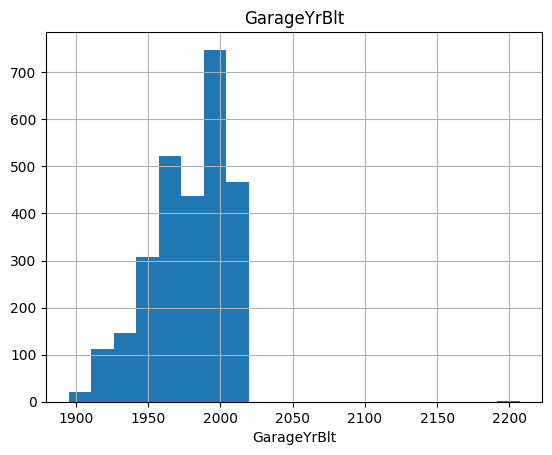

count   2918.000
mean     472.875
std      215.395
min        0.000
5%         0.000
10%      240.000
20%      296.000
30%      379.000
40%      440.000
50%      480.000
60%      513.000
70%      560.900
80%      621.000
90%      758.000
95%      856.150
99%     1019.490
max     1488.000
Name: GarageArea, dtype: float64
##########################################


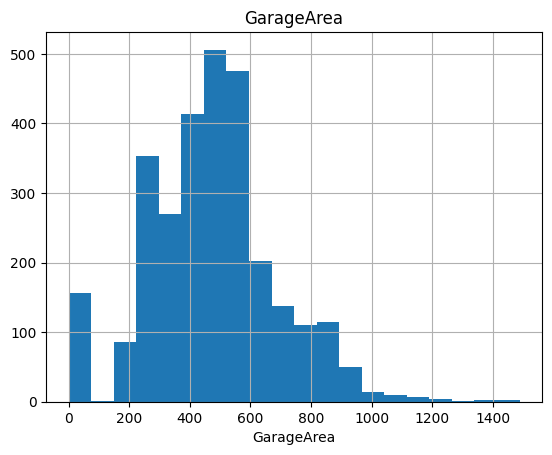

count   2919.000
mean      93.710
std      126.527
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%        0.000
50%        0.000
60%      100.000
70%      144.000
80%      192.000
90%      257.000
95%      328.000
99%      500.820
max     1424.000
Name: WoodDeckSF, dtype: float64
##########################################


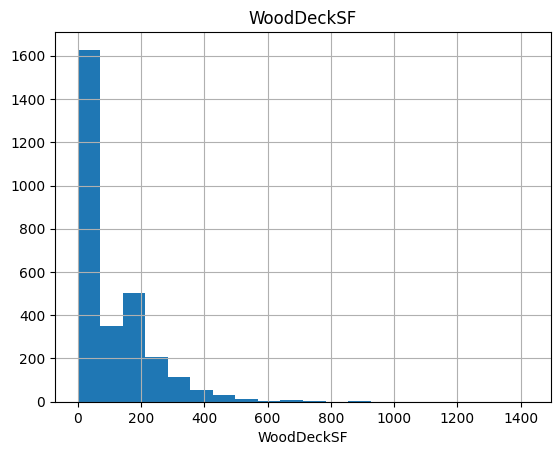

count   2919.000
mean      47.487
std       67.575
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%        0.000
50%       26.000
60%       40.000
70%       58.000
80%       85.000
90%      131.200
95%      183.100
99%      284.460
max      742.000
Name: OpenPorchSF, dtype: float64
##########################################


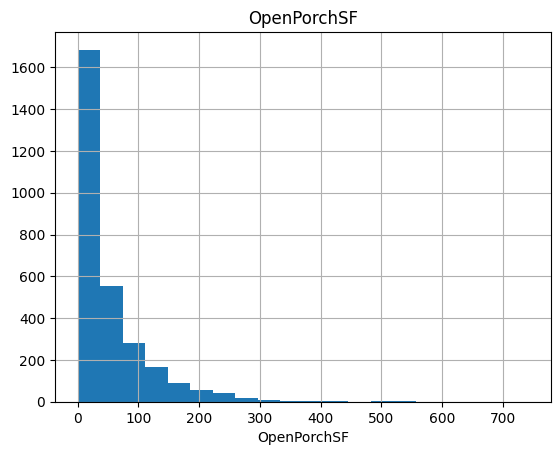

count   2919.000
mean      23.098
std       64.244
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%        0.000
50%        0.000
60%        0.000
70%        0.000
80%        0.000
90%      112.000
95%      176.000
99%      264.000
max     1012.000
Name: EnclosedPorch, dtype: float64
##########################################


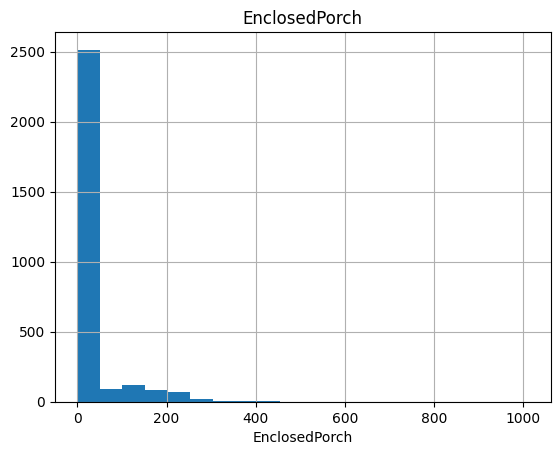

count   2919.000
mean       2.602
std       25.188
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%        0.000
50%        0.000
60%        0.000
70%        0.000
80%        0.000
90%        0.000
95%        0.000
99%      144.000
max      508.000
Name: 3SsnPorch, dtype: float64
##########################################


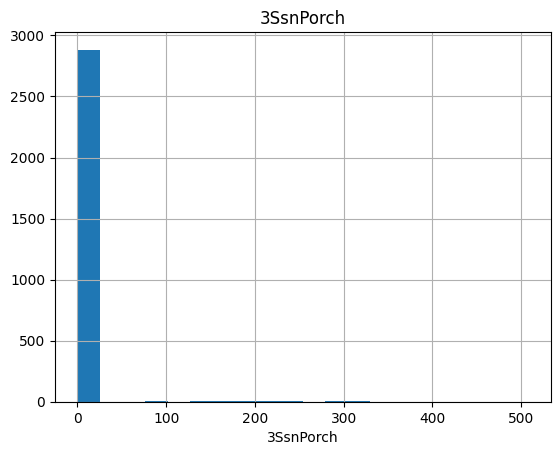

count   2919.000
mean      16.062
std       56.184
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%        0.000
50%        0.000
60%        0.000
70%        0.000
80%        0.000
90%        0.000
95%      161.000
99%      259.820
max      576.000
Name: ScreenPorch, dtype: float64
##########################################


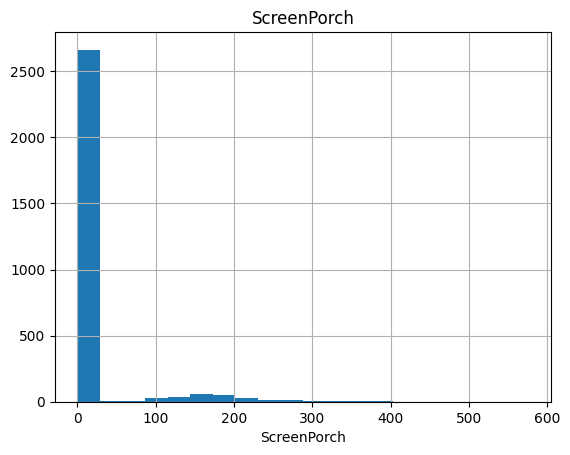

count   2919.000
mean       2.252
std       35.664
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%        0.000
50%        0.000
60%        0.000
70%        0.000
80%        0.000
90%        0.000
95%        0.000
99%        0.000
max      800.000
Name: PoolArea, dtype: float64
##########################################


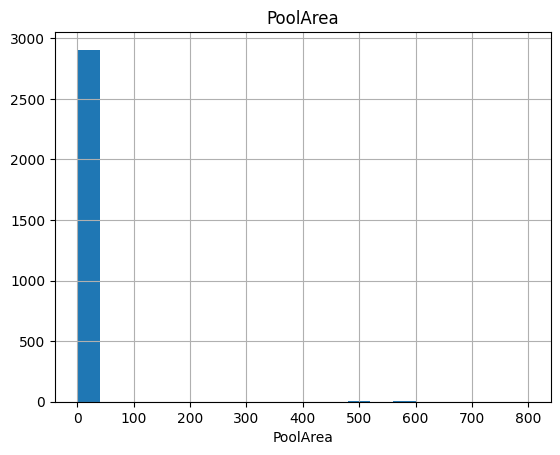

count    2919.000
mean       50.826
std       567.402
min         0.000
5%          0.000
10%         0.000
20%         0.000
30%         0.000
40%         0.000
50%         0.000
60%         0.000
70%         0.000
80%         0.000
90%         0.000
95%         0.000
99%       982.000
max     17000.000
Name: MiscVal, dtype: float64
##########################################


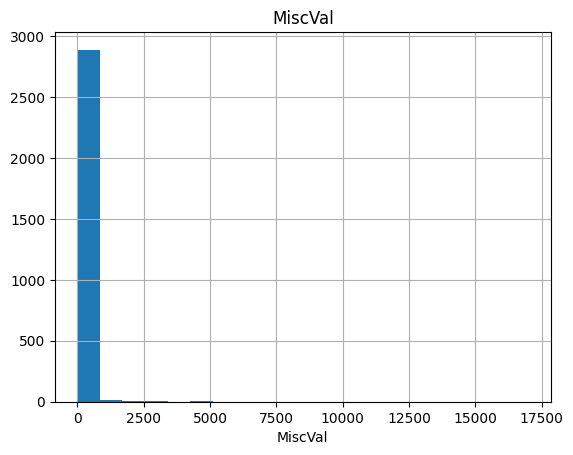

count   2919.000
mean       6.213
std        2.715
min        1.000
5%         2.000
10%        3.000
20%        4.000
30%        5.000
40%        6.000
50%        6.000
60%        7.000
70%        7.000
80%        8.000
90%       10.000
95%       11.000
99%       12.000
max       12.000
Name: MoSold, dtype: float64
##########################################


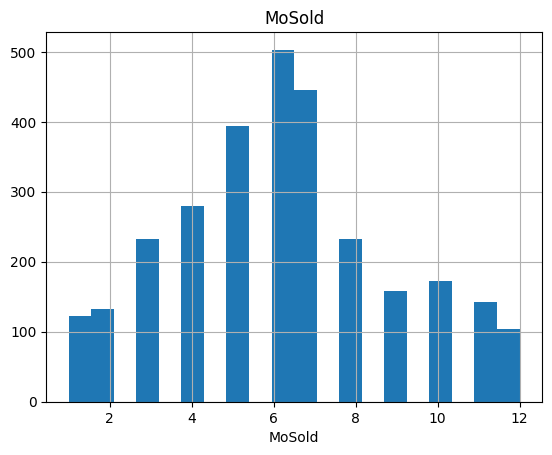

count     1460.000
mean    180921.196
std      79442.503
min      34900.000
5%       88000.000
10%     106475.000
20%     124000.000
30%     135500.000
40%     147000.000
50%     163000.000
60%     179280.000
70%     198620.000
80%     230000.000
90%     278000.000
95%     326100.000
99%     442567.010
max     755000.000
Name: SalePrice, dtype: float64
##########################################


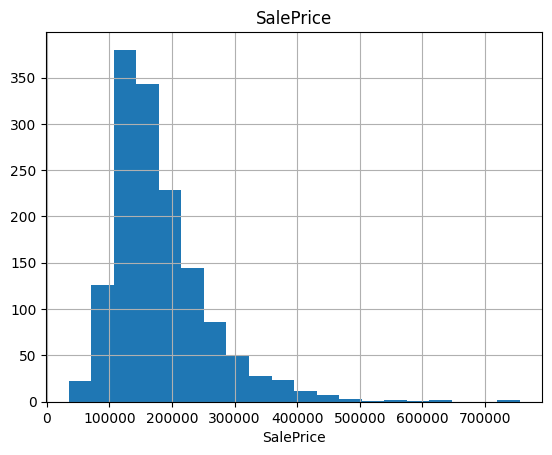

In [ ]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show()


for col in cat_cols:
    cat_summary(df, col)

def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)
    print("##########################################")
    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

for col in num_cols:
    num_summary(df, col, plot=True)

In [ ]:
def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean(),
                        "Count": dataframe[categorical_col].value_counts(),
                        "Ratio": 100 * dataframe[categorical_col].value_counts() / len(dataframe)}))
    print("##########################################")

for col in cat_cols:
    target_summary_with_cat(df, "SalePrice", col)

            TARGET_MEAN  Count  Ratio
MSSubClass                           
120          200779.080    182  6.235
150                 NaN      1  0.034
160          138647.381    128  4.385
180          102300.000     17  0.582
190          129613.333     61  2.090
20           185224.812   1079 36.965
30            95829.725    139  4.762
40           156125.000      6  0.206
45           108591.667     18  0.617
50           143302.972    287  9.832
60           239948.502    575 19.699
70           166772.417    128  4.385
75           192437.500     23  0.788
80           169736.552    118  4.042
85           147810.000     48  1.644
90           133541.077    109  3.734
##########################################
          TARGET_MEAN  Count  Ratio
MSZoning                           
C (all)     74528.000     25  0.856
FV         214014.062    139  4.762
RH         131558.375     26  0.891
RL         191004.995   2265 77.595
RM         126316.830    460 15.759
#####################

In [ ]:
def outlier_thresholds(dataframe, col_name, q1=0.01, q3=0.99):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

for col in num_cols:
  print(f"{col}: {check_outlier(df, col)}")

LotFrontage: True
LotArea: True
OverallQual: False
YearBuilt: False
YearRemodAdd: False
MasVnrArea: False
BsmtFinSF1: True
BsmtFinSF2: False
BsmtUnfSF: False
TotalBsmtSF: True
1stFlrSF: True
2ndFlrSF: False
LowQualFinSF: True
GrLivArea: False
TotRmsAbvGrd: False
GarageYrBlt: True
GarageArea: False
WoodDeckSF: True
OpenPorchSF: True
EnclosedPorch: True
3SsnPorch: True
ScreenPorch: False
PoolArea: True
MiscVal: True
MoSold: False
SalePrice: False


In [ ]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns

missing_cols = missing_values_table(df, na_name=True)

              n_miss  ratio
PoolQC          2909 99.660
MiscFeature     2814 96.400
Alley           2721 93.220
Fence           2348 80.440
MasVnrType      1766 60.500
SalePrice       1459 49.980
FireplaceQu     1420 48.650
LotFrontage      486 16.650
GarageQual       159  5.450
GarageYrBlt      159  5.450
GarageFinish     159  5.450
GarageCond       159  5.450
GarageType       157  5.380
BsmtCond          82  2.810
BsmtExposure      82  2.810
BsmtQual          81  2.770
BsmtFinType2      80  2.740
BsmtFinType1      79  2.710
MasVnrArea        23  0.790
MSZoning           4  0.140
Utilities          2  0.070
Functional         2  0.070
BsmtHalfBath       2  0.070
BsmtFullBath       2  0.070
BsmtFinSF1         1  0.030
Exterior2nd        1  0.030
Exterior1st        1  0.030
Electrical         1  0.030
TotalBsmtSF        1  0.030
BsmtUnfSF          1  0.030
BsmtFinSF2         1  0.030
GarageCars         1  0.030
KitchenQual        1  0.030
GarageArea         1  0.030
SaleType           1

In [ ]:
def replace_with_thresholds(dataframe, variable, q1=0.05, q3=0.95):
    low_limit, up_limit = outlier_thresholds(dataframe, variable, q1, q3)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit


for col in num_cols:
    if col != "SalePrice":
        replace_with_thresholds(df, col, q1=0.01, q3=0.99)

drop_list = ["PoolQC", "MiscFeature", "Alley", "Fence"]
df.drop(drop_list, axis=1, inplace=True)

cat_cols, num_cols, cat_but_car = grab_col_names(df)
num_cols = [col for col in num_cols if col not in ["Id"]]

Observations: 2919
Variables: 77
cat_cols: 50
num_cols: 26
cat_but_car: 1
num_but_cat: 11


/tmp/ipykernel_5371/1273135902.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-45357.96000000011' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
/tmp/ipykernel_5371/1273135902.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-7.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
/tmp/ipykernel_5371/1273135902.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1861.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] < low_limit), variable] 

In [ ]:
none_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in none_cols:
    df[col].fillna('None', inplace=True)

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    df[col].fillna(0, inplace=True)

/tmp/ipykernel_5371/3012632444.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('None', inplace=True)
/tmp/ipykernel_5371/3012632444.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.me

In [ ]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
df["FireplaceQu"].fillna("None", inplace=True)
df = df.apply(lambda x: x.fillna(x.mode()[0]) if (x.dtype == "O" and len(x.unique()) <= 10) else x, axis=0)

/tmp/ipykernel_5371/3995748698.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["FireplaceQu"].fillna("None", inplace=True)


In [ ]:
missing_values_table(df, na_name=True)
for col in num_cols:
  print(f"{col}: {check_outlier(df, col)}")

             n_miss  ratio
SalePrice      1459 49.980
Exterior1st       1  0.030
Exterior2nd       1  0.030


['Exterior1st', 'Exterior2nd', 'SalePrice']

LotFrontage: True
LotArea: False
OverallQual: False
YearBuilt: False
YearRemodAdd: False
MasVnrArea: False
BsmtFinSF1: True
BsmtFinSF2: False
BsmtUnfSF: False
TotalBsmtSF: True
1stFlrSF: False
2ndFlrSF: False
LowQualFinSF: False
GrLivArea: False
TotRmsAbvGrd: False
GarageYrBlt: False
GarageArea: False
WoodDeckSF: False
OpenPorchSF: False
EnclosedPorch: False
3SsnPorch: False
ScreenPorch: False
MiscVal: False
MoSold: False
SalePrice: False


In [ ]:
def rare_analyser(dataframe, target, cat_cols):
    for col in cat_cols:
        print(col, ":", len(dataframe[col].value_counts()))
        print(pd.DataFrame({"COUNT": dataframe[col].value_counts(),
                            "RATIO": dataframe[col].value_counts() / len(dataframe),
                            "TARGET_MEAN": dataframe.groupby(col)[target].mean()}))
        print("######################################\n")

rare_analyser(df, "SalePrice", cat_cols)



MSSubClass : 16
            COUNT  RATIO  TARGET_MEAN
MSSubClass                           
120           182  0.062   200779.080
150             1  0.000          NaN
160           128  0.044   138647.381
180            17  0.006   102300.000
190            61  0.021   129613.333
20           1079  0.370   185224.812
30            139  0.048    95829.725
40              6  0.002   156125.000
45             18  0.006   108591.667
50            287  0.098   143302.972
60            575  0.197   239948.502
70            128  0.044   166772.417
75             23  0.008   192437.500
80            118  0.040   169736.552
85             48  0.016   147810.000
90            109  0.037   133541.077
######################################

MSZoning : 5
          COUNT  RATIO  TARGET_MEAN
MSZoning                           
C (all)      25  0.009    74528.000
FV          139  0.048   214014.062
RH           26  0.009   131558.375
RL         2269  0.777   191004.995
RM          460  0.158   126316

In [ ]:

def rare_encoder(dataframe, rare_perc, cat_cols):
    temp_df = dataframe.copy()
    rare_columns = [col for col in cat_cols if (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)]

    for var in rare_columns:
        tmp = temp_df[var].value_counts() / len(temp_df)
        rare_labels = tmp[tmp < rare_perc].index
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), 'Rare', temp_df[var])

    return temp_df

df = rare_encoder(df, 0.01, cat_cols)

rare_analyser(df, "SalePrice", cat_cols)

MSSubClass : 12
            COUNT  RATIO  TARGET_MEAN
MSSubClass                           
120           182  0.062   200779.080
160           128  0.044   138647.381
190            61  0.021   129613.333
20           1079  0.370   185224.812
30            139  0.048    95829.725
50            287  0.098   143302.972
60            575  0.197   239948.502
70            128  0.044   166772.417
80            118  0.040   169736.552
85             48  0.016   147810.000
90            109  0.037   133541.077
Rare           65  0.022   143561.905
######################################

MSZoning : 4
          COUNT  RATIO  TARGET_MEAN
MSZoning                           
FV          139  0.048   214014.062
RL         2269  0.777   191004.995
RM          460  0.158   126316.830
Rare         51  0.017   109623.615
######################################

Street : 2
        COUNT  RATIO  TARGET_MEAN
Street                           
Pave     2907  0.996   181130.539
Rare       12  0.004   130190.

In [ ]:
cols_to_fix = ["BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath", "OverallQual", "TotRmsAbvGrd", "Fireplaces"]

for col in cols_to_fix:
    if df[col].dtype == 'O':
        df[col] = df[col].replace('Rare', np.nan)
        df[col] = pd.to_numeric(df[col])
        df[col] = df[col].fillna(df[col].median())

In [ ]:
#FEATURE EXTRACTION
#Ev yaşı
df["NEW_HouseAge"] = df["YrSold"] - df["YearBuilt"]
#ev restore edildi mi
df["NEW_IsRemodeled"] = np.where(df["YearBuilt"] == df["YearRemodAdd"], 0, 1)
#total alan 1.kat + 2.kat
df["NEW_TotalSqFt"] = df["GrLivArea"] + df["TotalBsmtSF"]
#total banyo sayısı
df["NEW_TotalBaths"] = df["BsmtFullBath"] + (df["BsmtHalfBath"] * 0.5) + df["FullBath"] + (df["HalfBath"] * 0.5)
#lüks özellikler garaj-havuz-şömine
df["NEW_HasPool"] = df["PoolArea"].apply(lambda x: 1 if x > 0 else 0)
df["NEW_HasFireplace"] = df["Fireplaces"].apply(lambda x: 1 if x > 0 else 0)
df["NEW_HasGarage"] = df["GarageArea"].apply(lambda x: 1 if x > 0 else 0)
#hem büyük hem kaliteli mi
df["NEW_Qual_x_Area"] = df["OverallQual"] * df["GrLivArea"]
#gerçek bahçe boyutu
df["NEW_YardArea"] = df["LotArea"] - df["1stFlrSF"] - df["GarageArea"]
df["NEW_YardArea"] = df["NEW_YardArea"].apply(lambda x: x if x > 0 else 0)
#oda büyüklüğü
df["NEW_AvgRoomSqFt"] = df["GrLivArea"] / (df["TotRmsAbvGrd"] + 1)
#total dış alan sayısı balkon vs.
df["NEW_TotalPorchArea"] = df["WoodDeckSF"] + df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
#yazın mı satıldı
df["NEW_IsSummerSale"] = df["MoSold"].isin([5, 6, 7, 8]).astype(int)

cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 2919
Variables: 89
cat_cols: 56
num_cols: 32
cat_but_car: 1
num_but_cat: 13


In [ ]:
from sklearn.preprocessing import LabelEncoder

binary_cols = [col for col in df.columns if df[col].dtype not in [int, float]
               and df[col].nunique() == 2]

def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

for col in binary_cols:
    df = label_encoder(df, col)

cat_cols, num_cols, cat_but_car = grab_col_names(df)
df.shape

Observations: 2919
Variables: 221
cat_cols: 188
num_cols: 32
cat_but_car: 1
num_but_cat: 188


(2919, 221)

In [ ]:
cat_cols, num_cols, cat_but_car = grab_col_names(df, car_th=30)

Observations: 2919
Variables: 221
cat_cols: 189
num_cols: 32
cat_but_car: 0
num_but_cat: 188


In [ ]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

df = one_hot_encoder(df, cat_cols, drop_first=True)
df.head()
df.shape

,Id,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,TotRmsAbvGrd,GarageYrBlt,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,MiscVal,MoSold,SalePrice,NEW_HouseAge,NEW_TotalSqFt,NEW_Qual_x_Area,NEW_YardArea,NEW_AvgRoomSqFt,NEW_TotalPorchArea,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,MSSubClass_160_1_True,MSSubClass_190_1_True,MSSubClass_20_1_True,MSSubClass_30_1_True,MSSubClass_50_1_True,MSSubClass_60_1_True,MSSubClass_70_1_True,MSSubClass_80_1_True,MSSubClass_85_1_True,MSSubClass_90_1_True,MSSubClass_Rare_1_True,MSZoning_RL_1_True,MSZoning_RM_1_True,MSZoning_Rare_1_True,LotShape_IR2_1_True,LotShape_Rare_1_True,LotShape_Reg_1_True,LandContour_HLS_1_True,LandContour_Low_1_True,LandContour_Lvl_1_True,LotConfig_CulDSac_1_True,LotConfig_FR2_1_True,LotConfig_Inside_1_True,LotConfig_Rare_1_True,LandSlope_Mod_1_True,LandSlope_Rare_1_True,Condition1_Feedr_1_True,Condition1_Norm_1_True,Condition1_PosN_1_True,Condition1_RRAn_1_True,Condition1_Rare_1_True,BldgType_2fmCon_1_True,BldgType_Duplex_1_True,BldgType_Twnhs_1_True,BldgType_TwnhsE_1_True,HouseStyle_1Story_1_True,HouseStyle_2Story_1_True,HouseStyle_Rare_1_True,HouseStyle_SFoyer_1_True,HouseStyle_SLvl_1_True,OverallCond_4_1_True,OverallCond_5_1_True,OverallCond_6_1_True,OverallCond_7_1_True,OverallCond_8_1_True,OverallCond_9_1_True,OverallCond_Rare_1_True,RoofStyle_Hip_1_True,RoofStyle_Rare_1_True,Exterior1st_BrkFace_1_True,Exterior1st_CemntBd_1_True,Exterior1st_HdBoard_1_True,Exterior1st_MetalSd_1_True,Exterior1st_Plywood_1_True,Exterior1st_Rare_1_True,Exterior1st_Stucco_1_True,Exterior1st_VinylSd_1_True,Exterior1st_Wd Sdng_1_True,Exterior1st_WdShing_1_True,Exterior2nd_BrkFace_1_True,Exterior2nd_CmentBd_1_True,Exterior2nd_HdBoard_1_True,Exterior2nd_MetalSd_1_True,Exterior2nd_Plywood_1_True,Exterior2nd_Rare_1_True,Exterior2nd_Stucco_1_True,Exterior2nd_VinylSd_1_True,Exterior2nd_Wd Sdng_1_True,Exterior2nd_Wd Shng_1_True,MasVnrType_None_1_True,MasVnrType_Rare_1_True,MasVnrType_Stone_1_True,ExterQual_Fa_1_True,ExterQual_Gd_1_True,ExterQual_TA_1_True,ExterCond_Gd_1_True,ExterCond_Rare_1_True,ExterCond_TA_1_True,Foundation_CBlock_1_True,Foundation_PConc_1_True,Foundation_Rare_1_True,Foundation_Slab_1_True,BsmtQual_Fa_1_True,BsmtQual_Gd_1_True,BsmtQual_None_1_True,BsmtQual_TA_1_True,BsmtCond_Gd_1_True,BsmtCond_None_1_True,BsmtCond_Rare_1_True,BsmtCond_TA_1_True,BsmtExposure_Gd_1_True,BsmtExposure_Mn_1_True,BsmtExposure_No_1_True,BsmtExposure_None_1_True,BsmtFinType1_BLQ_1_True,BsmtFinType1_GLQ_1_True,BsmtFinType1_LwQ_1_True,BsmtFinType1_None_1_True,BsmtFinType1_Rec_1_True,BsmtFinType1_Unf_1_True,BsmtFinType2_BLQ_1_True,BsmtFinType2_GLQ_1_True,BsmtFinType2_LwQ_1_True,BsmtFinType2_None_1_True,BsmtFinType2_Rec_1_True,BsmtFinType2_Unf_1_True,HeatingQC_Fa_1_True,HeatingQC_Gd_1_True,HeatingQC_Rare_1_True,HeatingQC_TA_1_True,Electrical_FuseF_1_True,Electrical_Rare_1_True,Electrical_SBrkr_1_True,BedroomAbvGr_2_1_True,BedroomAbvGr_3_1_True,BedroomAbvGr_4_1_True,BedroomAbvGr_5_1_True,BedroomAbvGr_Rare_1_True,KitchenAbvGr_2_1_True,KitchenAbvGr_Rare_1_True,KitchenQual_Fa_1_True,KitchenQual_Gd_1_True,KitchenQual_TA_1_True,Functional_Min2_1_True,Functional_Mod_1_True,Functional_Rare_1_True,Functional_Typ_1_True,FireplaceQu_Fa_1_True,FireplaceQu_Gd_1_True,FireplaceQu_None_1_True,FireplaceQu_Po_1_True,FireplaceQu_TA_1_True,GarageType_Basment_1_True,GarageType_BuiltIn_1_True,GarageType_Detchd_1_True,GarageType_None_1_True,GarageType_Rare_1

(2919, 244)

In [ ]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
test_df = df[df['SalePrice'].isnull()]
train_df = df[df['SalePrice'].notnull()]

y = train_df['SalePrice']
X = train_df.drop(["SalePrice", "Id"], axis=1)

X_test = test_df.drop(["SalePrice", "Id"], axis=1)

print("Train X Boyutu:", X.shape)
print("Train y Boyutu:", y.shape)
print("Test X Boyutu:", X_test.shape)

Train X Boyutu: (1460, 242)
Train y Boyutu: (1460,)
Test X Boyutu: (1459, 242)


In [ ]:
df.head()

,Id,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,TotRmsAbvGrd,GarageYrBlt,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,MiscVal,MoSold,SalePrice,NEW_HouseAge,NEW_TotalSqFt,NEW_Qual_x_Area,NEW_YardArea,NEW_AvgRoomSqFt,NEW_TotalPorchArea,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,MSSubClass_160_1_True,MSSubClass_190_1_True,MSSubClass_20_1_True,MSSubClass_30_1_True,MSSubClass_50_1_True,MSSubClass_60_1_True,MSSubClass_70_1_True,MSSubClass_80_1_True,MSSubClass_85_1_True,MSSubClass_90_1_True,MSSubClass_Rare_1_True,MSZoning_RL_1_True,MSZoning_RM_1_True,MSZoning_Rare_1_True,LotShape_IR2_1_True,LotShape_Rare_1_True,LotShape_Reg_1_True,LandContour_HLS_1_True,LandContour_Low_1_True,LandContour_Lvl_1_True,LotConfig_CulDSac_1_True,LotConfig_FR2_1_True,LotConfig_Inside_1_True,LotConfig_Rare_1_True,LandSlope_Mod_1_True,LandSlope_Rare_1_True,Condition1_Feedr_1_True,Condition1_Norm_1_True,Condition1_PosN_1_True,Condition1_RRAn_1_True,Condition1_Rare_1_True,BldgType_2fmCon_1_True,BldgType_Duplex_1_True,BldgType_Twnhs_1_True,BldgType_TwnhsE_1_True,HouseStyle_1Story_1_True,HouseStyle_2Story_1_True,HouseStyle_Rare_1_True,HouseStyle_SFoyer_1_True,HouseStyle_SLvl_1_True,OverallCond_4_1_True,OverallCond_5_1_True,OverallCond_6_1_True,OverallCond_7_1_True,OverallCond_8_1_True,OverallCond_9_1_True,OverallCond_Rare_1_True,RoofStyle_Hip_1_True,RoofStyle_Rare_1_True,Exterior1st_BrkFace_1_True,Exterior1st_CemntBd_1_True,Exterior1st_HdBoard_1_True,Exterior1st_MetalSd_1_True,Exterior1st_Plywood_1_True,Exterior1st_Rare_1_True,Exterior1st_Stucco_1_True,Exterior1st_VinylSd_1_True,Exterior1st_Wd Sdng_1_True,Exterior1st_WdShing_1_True,Exterior2nd_BrkFace_1_True,Exterior2nd_CmentBd_1_True,Exterior2nd_HdBoard_1_True,Exterior2nd_MetalSd_1_True,Exterior2nd_Plywood_1_True,Exterior2nd_Rare_1_True,Exterior2nd_Stucco_1_True,Exterior2nd_VinylSd_1_True,Exterior2nd_Wd Sdng_1_True,Exterior2nd_Wd Shng_1_True,MasVnrType_None_1_True,MasVnrType_Rare_1_True,MasVnrType_Stone_1_True,ExterQual_Fa_1_True,ExterQual_Gd_1_True,ExterQual_TA_1_True,ExterCond_Gd_1_True,ExterCond_Rare_1_True,ExterCond_TA_1_True,Foundation_CBlock_1_True,Foundation_PConc_1_True,Foundation_Rare_1_True,Foundation_Slab_1_True,BsmtQual_Fa_1_True,BsmtQual_Gd_1_True,BsmtQual_None_1_True,BsmtQual_TA_1_True,BsmtCond_Gd_1_True,BsmtCond_None_1_True,BsmtCond_Rare_1_True,BsmtCond_TA_1_True,BsmtExposure_Gd_1_True,BsmtExposure_Mn_1_True,BsmtExposure_No_1_True,BsmtExposure_None_1_True,BsmtFinType1_BLQ_1_True,BsmtFinType1_GLQ_1_True,BsmtFinType1_LwQ_1_True,BsmtFinType1_None_1_True,BsmtFinType1_Rec_1_True,BsmtFinType1_Unf_1_True,BsmtFinType2_BLQ_1_True,BsmtFinType2_GLQ_1_True,BsmtFinType2_LwQ_1_True,BsmtFinType2_None_1_True,BsmtFinType2_Rec_1_True,BsmtFinType2_Unf_1_True,HeatingQC_Fa_1_True,HeatingQC_Gd_1_True,HeatingQC_Rare_1_True,HeatingQC_TA_1_True,Electrical_FuseF_1_True,Electrical_Rare_1_True,Electrical_SBrkr_1_True,BedroomAbvGr_2_1_True,BedroomAbvGr_3_1_True,BedroomAbvGr_4_1_True,BedroomAbvGr_5_1_True,BedroomAbvGr_Rare_1_True,KitchenAbvGr_2_1_True,KitchenAbvGr_Rare_1_True,KitchenQual_Fa_1_True,KitchenQual_Gd_1_True,KitchenQual_TA_1_True,Functional_Min2_1_True,Functional_Mod_1_True,Functional_Rare_1_True,Functional_Typ_1_True,FireplaceQu_Fa_1_True,FireplaceQu_Gd_1_True,FireplaceQu_None_1_True,FireplaceQu_Po_1_True,FireplaceQu_TA_1_True,GarageType_Basment_1_True,GarageType_BuiltIn_1_True,GarageType_Detchd_1_True,GarageType_None_1_True,GarageType_Rare_1

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

rf_model = RandomForestRegressor(random_state=46)

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="neg_root_mean_squared_error")

rmse_mean = np.mean(-cv_scores)

print(f"Random Forest Ortalama RMSE: {rmse_mean:.2f}")
#29944.23

Random Forest Ortalama RMSE: 29955.54


In [ ]:
from sklearn.compose import TransformedTargetRegressor
log_rf_model = TransformedTargetRegressor(
    regressor=RandomForestRegressor(random_state=46),
    func=np.log1p,
    inverse_func=np.expm1
)

cv_scores_log = cross_val_score(log_rf_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
rmse_mean_log = np.mean(-cv_scores_log)

print(f"Log Dönüşümlü Random Forest RMSE: {rmse_mean_log:.2f}")
#29812.63

Log Dönüşümlü Random Forest RMSE: 29812.63


In [208]:
from sklearn.model_selection import GridSearchCV
rf_params = {
    "max_depth": [8, 15, None],
    "min_samples_split": [2, 5, 10],
    "n_estimators": [100, 300, 500]
}


rf_gs = GridSearchCV(rf_model, rf_params, cv=5, n_jobs=-1, verbose=1).fit(X, y)

rf_gs.best_params_

Fitting 5 folds for each of 27 candidates, totalling 135 fits


{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}

Hiperparametre Optimizasyonu Sonrası RMSE: 30109.86


RandomForestRegressor(max_depth=15, min_samples_split=5, random_state=46)

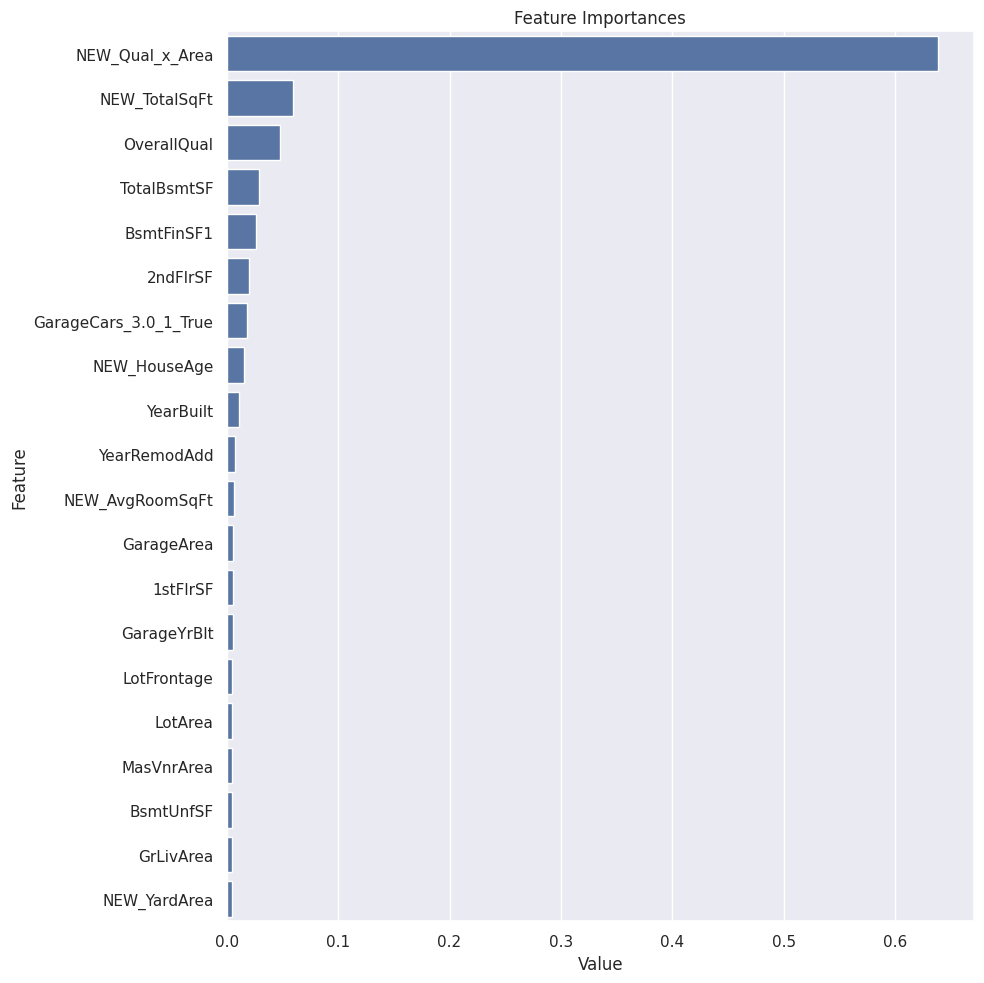

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns

rf_final = RandomForestRegressor(max_depth=15,
                                 min_samples_split=5,
                                 n_estimators=100,
                                 random_state=46)

cv_scores_final = cross_val_score(rf_final, X, y, cv=5, scoring="neg_root_mean_squared_error")
rmse_final = np.mean(-cv_scores_final)

print(f"Hiperparametre Optimizasyonu Sonrası RMSE: {rmse_final:.2f}")

def plot_importance(model, features, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)

    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False)[0:num])
    plt.title('Feature Importances')
    plt.tight_layout()
    if save:
        plt.savefig('importances.png')
    plt.show()

rf_final.fit(X, y)

plot_importance(rf_final, X, num=20)

In [211]:
predictions = rf_final.predict(X_test)
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": predictions
})
submission.to_csv("submission_1.csv", index=False)

In [2]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

In [3]:
xgb_model = XGBRegressor(random_state=46)
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
rmse_xgb = np.mean(-cv_scores_xgb)

NameError: name 'X' is not defined